===========================================
XGBOOST - AJUSTE FINO PARA MAXIMIZAR RECALL
Hospital F5 - Optimización enfocada en Sensibilidad
===========================================

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, recall_score, precision_score, 
                             f1_score, make_scorer)
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🎯 AJUSTE FINO - MAXIMIZAR RECALL")
print("="*60)

🎯 AJUSTE FINO - MAXIMIZAR RECALL


In [4]:
# ===========================================
# 1. CARGA DE DATOS
# ===========================================
print("\n📁 1. CARGANDO DATOS...")

import os
import pickle

print("\n📁 1. CARGANDO DATOS PREPROCESADOS...")

# === INSTALAR gdown SI ES NECESARIO ===
try:
    import gdown
except ImportError:
    raise ImportError("⚠️ Debes instalar gdown. Ejecuta en una celda: !pip install gdown")

# === DESCARGA DEL ARCHIVO DESDE GOOGLE DRIVE ===
file_id = '1Q0SYA3qsqDVfTqVIaCIiOmxvBU0c2M9M'
output_path = os.path.join(os.getcwd(), 'preprocessed_data_temp.pkl')

print(f"⬇️ Descargando archivo desde Google Drive (ID: {file_id})...")
gdown.download(id=file_id, output=output_path, quiet=False)

# Verificar descarga
if not os.path.exists(output_path):
    raise FileNotFoundError(f"❌ No se pudo descargar el archivo desde Google Drive.\nRuta esperada: {output_path}")

print(f"✅ Archivo descargado en: {output_path}")

# === CARGA DEL PICKLE ===
with open(output_path, 'rb') as f:
    datasets = pickle.load(f)

# === EXTRACCIÓN DE DATOS ===
X_train_original, X_test, y_train_original, y_test = datasets['original']
scaler = datasets['scaler']
feature_names = datasets['feature_names']

# === INFO DE LOS DATOS ===
print("\n✅ Datos cargados correctamente:")
print(f"   ➤ X_train_original: {X_train_original.shape}")
print(f"   ➤ X_test: {X_test.shape}")
print(f"   ➤ Casos positivos en y_train: {(y_train_original == 1).sum()}")
print(f"   ➤ Total de características: {len(feature_names)}")


📁 1. CARGANDO DATOS...

📁 1. CARGANDO DATOS PREPROCESADOS...
⬇️ Descargando archivo desde Google Drive (ID: 1Q0SYA3qsqDVfTqVIaCIiOmxvBU0c2M9M)...


Downloading...
From: https://drive.google.com/uc?id=1Q0SYA3qsqDVfTqVIaCIiOmxvBU0c2M9M
To: c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\notebooks\preprocessed_data_temp.pkl
100%|██████████| 2.18M/2.18M [00:00<00:00, 7.17MB/s]


✅ Archivo descargado en: c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\notebooks\preprocessed_data_temp.pkl

✅ Datos cargados correctamente:
   ➤ X_train_original: (3984, 25)
   ➤ X_test: (997, 25)
   ➤ Casos positivos en y_train: 198
   ➤ Total de características: 25


In [6]:
# ===========================================
# 2. GRID DE CONFIGURACIONES OPTIMIZADAS
# ===========================================
print("\n" + "="*60)
print("⚙️ 2. PROBANDO CONFIGURACIONES OPTIMIZADAS")
print("="*60)

# Diferentes configuraciones enfocadas en recall
configs = [
    {
        'name': 'Config_1_Aggressive',
        'params': {
            'n_estimators': 300,
            'max_depth': 3,
            'learning_rate': 0.03,
            'min_child_weight': 1,
            'gamma': 0.2,
            'subsample': 0.7,
            'colsample_bytree': 0.7,
            'scale_pos_weight': 35,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'eval_metric': 'aucpr',
            'random_state': 42,
            'n_jobs': 1
        }
    },
    {
        'name': 'Config_2_Balanced',
        'params': {
            'n_estimators': 400,
            'max_depth': 4,
            'learning_rate': 0.02,
            'min_child_weight': 2,
            'gamma': 0.15,
            'subsample': 0.75,
            'colsample_bytree': 0.75,
            'scale_pos_weight': 28,
            'reg_alpha': 0.05,
            'reg_lambda': 0.5,
            'eval_metric': 'aucpr',
            'random_state': 42,
            'n_jobs': 1
        }
    },
    {
        'name': 'Config_3_Conservative',
        'params': {
            'n_estimators': 500,
            'max_depth': 3,
            'learning_rate': 0.01,
            'min_child_weight': 3,
            'gamma': 0.25,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'scale_pos_weight': 25,
            'reg_alpha': 0.2,
            'reg_lambda': 1.5,
            'eval_metric': 'aucpr',
            'random_state': 42,
            'n_jobs': 1
        }
    },
    {
        'name': 'Config_4_VeryAggressive',
        'params': {
            'n_estimators': 350,
            'max_depth': 2,
            'learning_rate': 0.04,
            'min_child_weight': 1,
            'gamma': 0.1,
            'subsample': 0.65,
            'colsample_bytree': 0.65,
            'scale_pos_weight': 40,
            'reg_alpha': 0,
            'reg_lambda': 0.5,
            'eval_metric': 'aucpr',
            'random_state': 42,
            'n_jobs': 1
        }
    },
    {
        'name': 'Config_5_DeepTrees',
        'params': {
            'n_estimators': 250,
            'max_depth': 5,
            'learning_rate': 0.025,
            'min_child_weight': 1,
            'gamma': 0.15,
            'subsample': 0.7,
            'colsample_bytree': 0.7,
            'scale_pos_weight': 32,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'eval_metric': 'aucpr',
            'random_state': 42,
            'n_jobs': 1
        }
    }
]

resultados = {}

for config in configs:
    print(f"\n🔹 Entrenando: {config['name']}...")
    
    model = XGBClassifier(**config['params'])
    model.fit(X_train_original, y_train_original)
    
    # Predicciones
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Métricas
    resultados[config['name']] = {
        'model': model,
        'recall': recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_pred_proba),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'params': config['params']
    }
    
    print(f"   Recall: {resultados[config['name']]['recall']:.4f} | "
          f"Precision: {resultados[config['name']]['precision']:.4f} | "
          f"F1: {resultados[config['name']]['f1']:.4f} | "
          f"AUC: {resultados[config['name']]['auc']:.4f}")


⚙️ 2. PROBANDO CONFIGURACIONES OPTIMIZADAS

🔹 Entrenando: Config_1_Aggressive...
   Recall: 0.8400 | Precision: 0.1346 | F1: 0.2320 | AUC: 0.8493

🔹 Entrenando: Config_2_Balanced...
   Recall: 0.7200 | Precision: 0.1457 | F1: 0.2424 | AUC: 0.8460

🔹 Entrenando: Config_3_Conservative...
   Recall: 0.9000 | Precision: 0.1438 | F1: 0.2479 | AUC: 0.8568

🔹 Entrenando: Config_4_VeryAggressive...
   Recall: 0.9000 | Precision: 0.1286 | F1: 0.2250 | AUC: 0.8535

🔹 Entrenando: Config_5_DeepTrees...
   Recall: 0.7200 | Precision: 0.1552 | F1: 0.2553 | AUC: 0.8480


In [7]:
# ===========================================
# 3. COMPARACIÓN Y SELECCIÓN
# ===========================================
print("\n" + "="*60)
print("📊 3. COMPARACIÓN DE CONFIGURACIONES")
print("="*60)

df_comp = pd.DataFrame({
    'Config': list(resultados.keys()),
    'Recall': [resultados[k]['recall'] for k in resultados.keys()],
    'Precision': [resultados[k]['precision'] for k in resultados.keys()],
    'F1-Score': [resultados[k]['f1'] for k in resultados.keys()],
    'AUC-ROC': [resultados[k]['auc'] for k in resultados.keys()]
})

# Calcular score ponderado (70% recall, 30% F1)
df_comp['Score_Ponderado'] = df_comp['Recall'] * 0.7 + df_comp['F1-Score'] * 0.3

print("\n" + df_comp.to_string(index=False))

# Mejor modelo
best_idx = df_comp['Score_Ponderado'].idxmax()
best_config_name = df_comp.loc[best_idx, 'Config']
best_model = resultados[best_config_name]['model']

print(f"\n🏆 MEJOR CONFIGURACIÓN: {best_config_name}")
print(f"   Recall:    {resultados[best_config_name]['recall']:.4f} ⭐")
print(f"   Precision: {resultados[best_config_name]['precision']:.4f}")
print(f"   F1-Score:  {resultados[best_config_name]['f1']:.4f}")
print(f"   AUC-ROC:   {resultados[best_config_name]['auc']:.4f}")


📊 3. COMPARACIÓN DE CONFIGURACIONES

                 Config  Recall  Precision  F1-Score  AUC-ROC  Score_Ponderado
    Config_1_Aggressive    0.84   0.134615  0.232044 0.849314         0.657613
      Config_2_Balanced    0.72   0.145749  0.242424 0.846019         0.576727
  Config_3_Conservative    0.90   0.143770  0.247934 0.856811         0.704380
Config_4_VeryAggressive    0.90   0.128571  0.225000 0.853527         0.697500
     Config_5_DeepTrees    0.72   0.155172  0.255319 0.847962         0.580596

🏆 MEJOR CONFIGURACIÓN: Config_3_Conservative
   Recall:    0.9000 ⭐
   Precision: 0.1438
   F1-Score:  0.2479
   AUC-ROC:   0.8568


In [9]:
# ===========================================
# 4. VALIDACIÓN CRUZADA DEL MEJOR
# ===========================================
print("\n" + "="*60)
print("🔄 4. VALIDACIÓN CRUZADA (5-FOLD)")
print("="*60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nEjecutando validación cruzada (puede tardar unos minutos)...")
cv_recall = cross_val_score(best_model, X_train_original, y_train_original, cv=skf, scoring='recall', n_jobs=1)
cv_precision = cross_val_score(best_model, X_train_original, y_train_original, cv=skf, scoring='precision', n_jobs=1)
cv_f1 = cross_val_score(best_model, X_train_original, y_train_original, cv=skf, scoring='f1', n_jobs=1)

print(f"\n📊 Resultados por fold:")
for i in range(5):
    print(f"   Fold {i+1}: Recall={cv_recall[i]:.4f}, Precision={cv_precision[i]:.4f}, F1={cv_f1[i]:.4f}")

print(f"\n📈 Promedios:")
print(f"   Recall:    {cv_recall.mean():.4f} (±{cv_recall.std():.4f})")
print(f"   Precision: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})")
print(f"   F1-Score:  {cv_f1.mean():.4f} (±{cv_f1.std():.4f})")


🔄 4. VALIDACIÓN CRUZADA (5-FOLD)

Ejecutando validación cruzada (puede tardar unos minutos)...

📊 Resultados por fold:
   Fold 1: Recall=0.7692, Precision=0.1351, F1=0.2299
   Fold 2: Recall=0.7250, Precision=0.1142, F1=0.1973
   Fold 3: Recall=0.6750, Precision=0.1051, F1=0.1818
   Fold 4: Recall=0.8250, Precision=0.1269, F1=0.2200
   Fold 5: Recall=0.9231, Precision=0.1338, F1=0.2338

📈 Promedios:
   Recall:    0.7835 (±0.0856)
   Precision: 0.1230 (±0.0117)
   F1-Score:  0.2125 (±0.0199)


In [12]:
# ===========================================
# 5. ANÁLISIS DE OVERFITTING
# ===========================================
print("\n" + "="*60)
print("🔍 5. ANÁLISIS DE OVERFITTING")
print("="*60)

y_train_pred = best_model.predict(X_train_original)
y_test_pred = resultados[best_config_name]['y_pred']

metrics_train = {
    'recall': recall_score(y_train_original, y_train_pred),
    'precision': precision_score(y_train_original, y_train_pred),
    'f1': f1_score(y_train_original, y_train_pred)
}

metrics_test = {
    'recall': resultados[best_config_name]['recall'],
    'precision': resultados[best_config_name]['precision'],
    'f1': resultados[best_config_name]['f1']
}

print(f"\n📊 Comparación Train vs Test:")
for metric in metrics_train.keys():
    diff = abs(metrics_train[metric] - metrics_test[metric]) * 100
    status = '✅' if diff < 5 else '⚠️' if diff < 10 else '❌'
    print(f"   {metric.upper():<12} Train: {metrics_train[metric]:.4f}  Test: {metrics_test[metric]:.4f}  Diff: {diff:.2f}% {status}")


🔍 5. ANÁLISIS DE OVERFITTING

📊 Comparación Train vs Test:
   RECALL       Train: 0.9343  Test: 0.9000  Diff: 3.43% ✅
   PRECISION    Train: 0.1402  Test: 0.1438  Diff: 0.36% ✅
   F1           Train: 0.2437  Test: 0.2479  Diff: 0.42% ✅


In [13]:
# ===========================================
# 6. OPTIMIZACIÓN DE THRESHOLD
# ===========================================
print("\n" + "="*60)
print("🎚️ 6. OPTIMIZACIÓN DE THRESHOLD")
print("="*60)

thresholds = np.arange(0.05, 0.5, 0.05)
threshold_results = []

y_pred_proba_best = resultados[best_config_name]['y_pred_proba']

for t in thresholds:
    y_pred_t = (y_pred_proba_best >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    if (tp + fp) > 0:
        prec = tp / (tp + fp)
    else:
        prec = 0
    
    threshold_results.append({
        'threshold': t,
        'recall': recall_score(y_test, y_pred_t),
        'precision': prec,
        'f1': f1_score(y_test, y_pred_t) if (tp + fp) > 0 else 0,
        'fn': fn,
        'tp': tp,
        'fp': fp
    })

df_thresh = pd.DataFrame(threshold_results)

# Mejor threshold para maximizar recall manteniendo precision razonable (>0.12)
df_filtered = df_thresh[df_thresh['precision'] >= 0.12]
if len(df_filtered) > 0:
    best_t_idx = df_filtered['recall'].idxmax()
    best_t = df_filtered.loc[best_t_idx, 'threshold']
else:
    best_t_idx = df_thresh['f1'].idxmax()
    best_t = df_thresh.loc[best_t_idx, 'threshold']

print(f"\n🎯 Threshold óptimo: {best_t:.2f}")
print(f"   Recall:    {df_thresh.loc[df_thresh['threshold']==best_t, 'recall'].values[0]:.4f}")
print(f"   Precision: {df_thresh.loc[df_thresh['threshold']==best_t, 'precision'].values[0]:.4f}")
print(f"   F1-Score:  {df_thresh.loc[df_thresh['threshold']==best_t, 'f1'].values[0]:.4f}")
print(f"   Verdaderos Positivos: {int(df_thresh.loc[df_thresh['threshold']==best_t, 'tp'].values[0])}")
print(f"   Falsos Negativos: {int(df_thresh.loc[df_thresh['threshold']==best_t, 'fn'].values[0])}")


🎚️ 6. OPTIMIZACIÓN DE THRESHOLD

🎯 Threshold óptimo: 0.40
   Recall:    0.9200
   Precision: 0.1257
   F1-Score:  0.2212
   Verdaderos Positivos: 46
   Falsos Negativos: 4



📈 7. GENERANDO VISUALIZACIONES

✅ Gráfico guardado: xgboost_fine_tuned_results.png


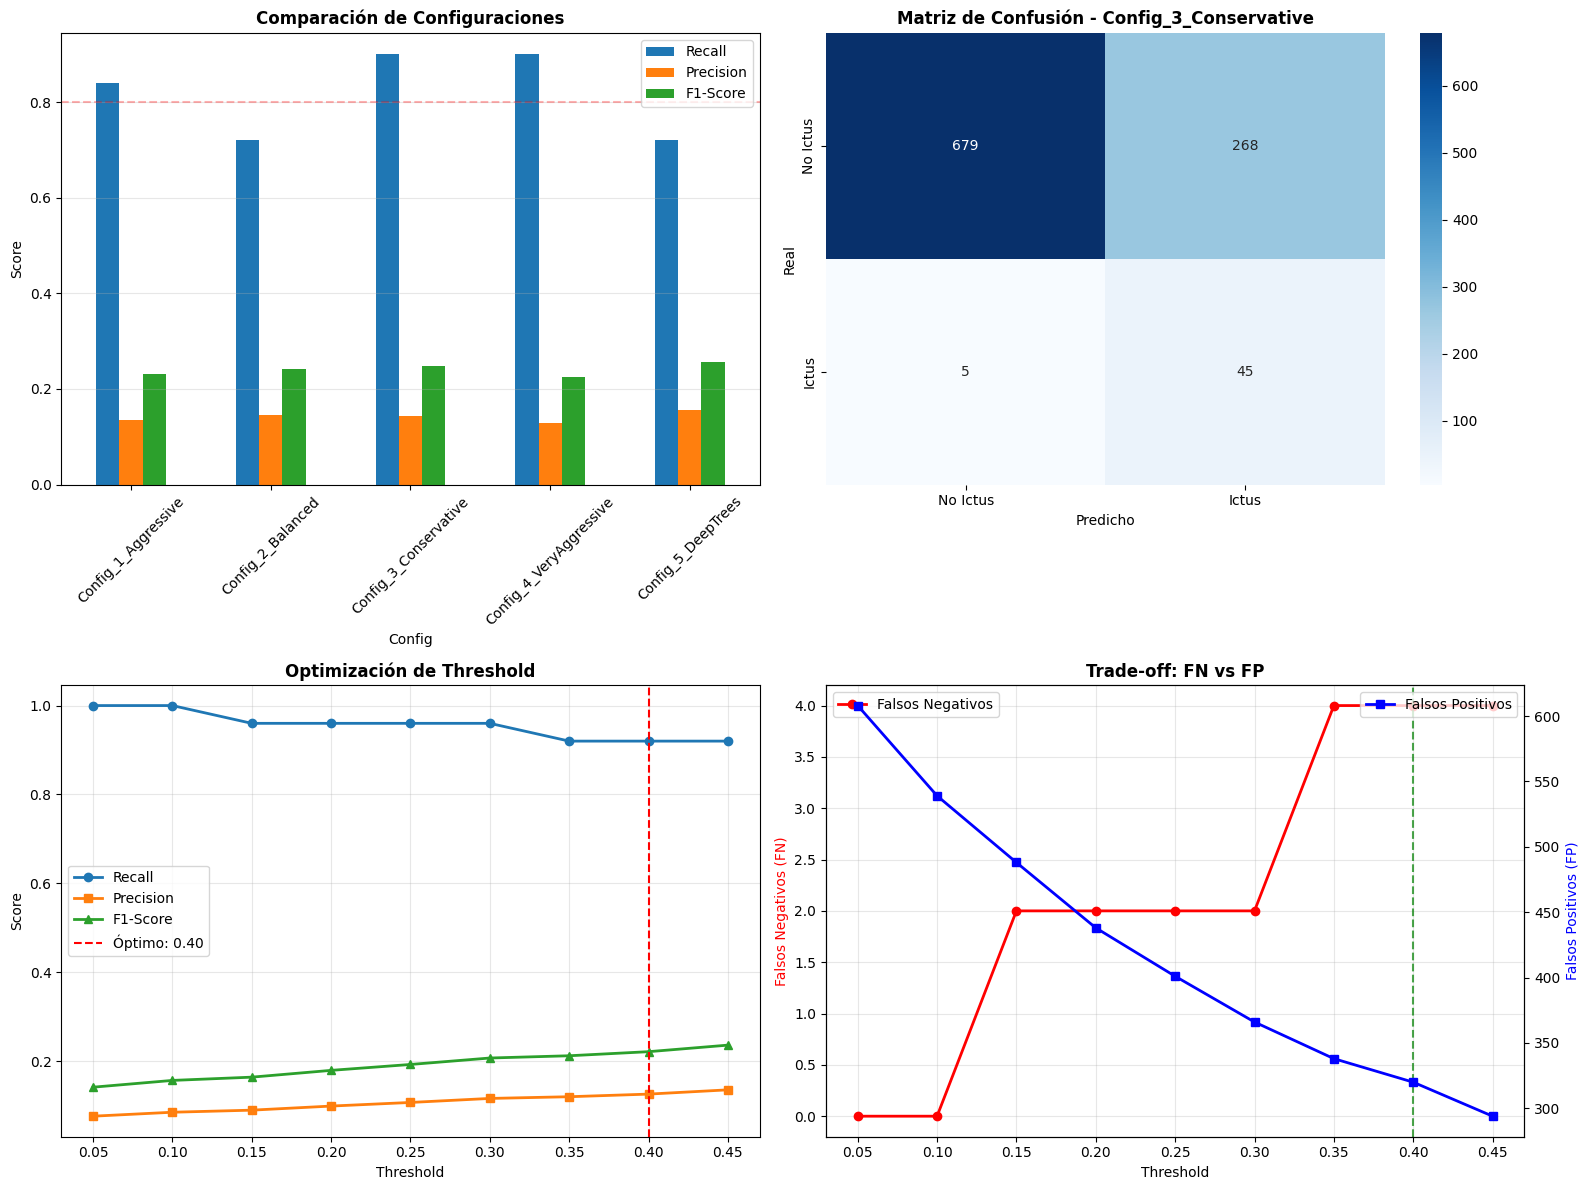

In [14]:
# ===========================================
# 7. VISUALIZACIONES
# ===========================================
print("\n" + "="*60)
print("📈 7. GENERANDO VISUALIZACIONES")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Comparación de configuraciones
df_comp[['Config', 'Recall', 'Precision', 'F1-Score']].set_index('Config').plot(
    kind='bar', ax=axes[0, 0], rot=45)
axes[0, 0].set_title('Comparación de Configuraciones', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Score')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(alpha=0.3, axis='y')
axes[0, 0].axhline(y=0.8, color='red', linestyle='--', alpha=0.3, label='Target Recall')

# Gráfico 2: Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['No Ictus', 'Ictus'],
            yticklabels=['No Ictus', 'Ictus'])
axes[0, 1].set_title(f'Matriz de Confusión - {best_config_name}', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Real')
axes[0, 1].set_xlabel('Predicho')

# Gráfico 3: Threshold vs Métricas
axes[1, 0].plot(df_thresh['threshold'], df_thresh['recall'], 'o-', label='Recall', linewidth=2)
axes[1, 0].plot(df_thresh['threshold'], df_thresh['precision'], 's-', label='Precision', linewidth=2)
axes[1, 0].plot(df_thresh['threshold'], df_thresh['f1'], '^-', label='F1-Score', linewidth=2)
axes[1, 0].axvline(x=best_t, color='red', linestyle='--', label=f'Óptimo: {best_t:.2f}')
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Optimización de Threshold', fontweight='bold', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Gráfico 4: Trade-off FN vs FP
ax2 = axes[1, 1].twinx()
axes[1, 1].plot(df_thresh['threshold'], df_thresh['fn'], 'ro-', label='Falsos Negativos', linewidth=2)
ax2.plot(df_thresh['threshold'], df_thresh['fp'], 'bs-', label='Falsos Positivos', linewidth=2)
axes[1, 1].axvline(x=best_t, color='green', linestyle='--', alpha=0.7)
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('Falsos Negativos (FN)', color='red')
ax2.set_ylabel('Falsos Positivos (FP)', color='blue')
axes[1, 1].set_title('Trade-off: FN vs FP', fontweight='bold', fontsize=12)
axes[1, 1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_fine_tuned_results.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfico guardado: xgboost_fine_tuned_results.png")
plt.show()

In [15]:
# ===========================================
# 8. GUARDAR MODELO FINAL
# ===========================================
print("\n" + "="*60)
print("💾 8. GUARDADO DEL MODELO FINAL")
print("="*60)

model_package = {
    'model': best_model,
    'config_name': best_config_name,
    'params': resultados[best_config_name]['params'],
    'scaler': scaler,
    'feature_names': feature_names,
    'threshold_default': 0.5,
    'threshold_optimized': best_t,
    'metrics': {
        'test': metrics_test,
        'train': metrics_train,
        'cv': {
            'recall_mean': cv_recall.mean(),
            'recall_std': cv_recall.std(),
            'precision_mean': cv_precision.mean(),
            'precision_std': cv_precision.std(),
            'f1_mean': cv_f1.mean(),
            'f1_std': cv_f1.std()
        }
    }
}

with open('xgboost_final_optimized.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("✅ Modelo guardado: xgboost_final_optimized.pkl")


💾 8. GUARDADO DEL MODELO FINAL
✅ Modelo guardado: xgboost_final_optimized.pkl


In [16]:
# ===========================================
# 9. RESUMEN EJECUTIVO
# ===========================================
print("\n" + "="*60)
print("📋 9. RESUMEN EJECUTIVO FINAL")
print("="*60)

tn, fp, fn, tp = cm.ravel()

print(f"""
🏆 MEJOR CONFIGURACIÓN: {best_config_name}

📊 MÉTRICAS EN TEST (threshold = 0.5):
   • Recall (Sensibilidad):  {metrics_test['recall']:.4f} ⭐
   • Precision (VPP):        {metrics_test['precision']:.4f}
   • F1-Score:               {metrics_test['f1']:.4f}
   • AUC-ROC:                {resultados[best_config_name]['auc']:.4f}

🎚️ CON THRESHOLD OPTIMIZADO ({best_t:.2f}):
   • Recall:    {df_thresh.loc[df_thresh['threshold']==best_t, 'recall'].values[0]:.4f}
   • Precision: {df_thresh.loc[df_thresh['threshold']==best_t, 'precision'].values[0]:.4f}
   • F1-Score:  {df_thresh.loc[df_thresh['threshold']==best_t, 'f1'].values[0]:.4f}

🔍 VALIDACIÓN CRUZADA (5-fold):
   • Recall:    {cv_recall.mean():.4f} (±{cv_recall.std():.4f})
   • Precision: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})
   • F1-Score:  {cv_f1.mean():.4f} (±{cv_f1.std():.4f})

⚕️ ANÁLISIS MÉDICO:
   • Total de casos con ictus en test: {tp + fn}
   • Casos detectados correctamente: {tp} ({tp/(tp+fn)*100:.1f}%)
   • Casos NO detectados (FN): {fn} ⚠️
   • Pacientes sanos derivados (FP): {fp}
   
💡 INTERPRETACIÓN CLÍNICA:
""")

recall_val = metrics_test['recall']
if recall_val >= 0.80:
    print("   ✅ EXCELENTE sensibilidad para screening")
    print("   ✅ Detecta la gran mayoría de casos de ictus")
    print("   📌 Usar como herramienta de TRIAJE inicial")
elif recall_val >= 0.70:
    print("   ✅ BUENA sensibilidad para screening")
    print("   ⚠️  Pierde algunos casos (revisar threshold)")
    print("   📌 Válido como apoyo al diagnóstico")
else:
    print("   ⚠️  Sensibilidad MEJORABLE")
    print("   ❌ Pierde demasiados casos reales")
    print("   📌 Necesita más optimización")

print(f"""
📁 ARCHIVOS GENERADOS:
   • xgboost_final_optimized.pkl
   • xgboost_fine_tuned_results.png

🎯 SIGUIENTE PASO: Implementar aplicación CLI/Streamlit
""")

print("="*60)
print("✅ AJUSTE FINO COMPLETADO")
print("="*60)


📋 9. RESUMEN EJECUTIVO FINAL

🏆 MEJOR CONFIGURACIÓN: Config_3_Conservative

📊 MÉTRICAS EN TEST (threshold = 0.5):
   • Recall (Sensibilidad):  0.9000 ⭐
   • Precision (VPP):        0.1438
   • F1-Score:               0.2479
   • AUC-ROC:                0.8568

🎚️ CON THRESHOLD OPTIMIZADO (0.40):
   • Recall:    0.9200
   • Precision: 0.1257
   • F1-Score:  0.2212

🔍 VALIDACIÓN CRUZADA (5-fold):
   • Recall:    0.7835 (±0.0856)
   • Precision: 0.1230 (±0.0117)
   • F1-Score:  0.2125 (±0.0199)

⚕️ ANÁLISIS MÉDICO:
   • Total de casos con ictus en test: 50
   • Casos detectados correctamente: 45 (90.0%)
   • Casos NO detectados (FN): 5 ⚠️
   • Pacientes sanos derivados (FP): 268

💡 INTERPRETACIÓN CLÍNICA:

   ✅ EXCELENTE sensibilidad para screening
   ✅ Detecta la gran mayoría de casos de ictus
   📌 Usar como herramienta de TRIAJE inicial

📁 ARCHIVOS GENERADOS:
   • xgboost_final_optimized.pkl
   • xgboost_fine_tuned_results.png

🎯 SIGUIENTE PASO: Implementar aplicación CLI/Streamlit

✅ 